# A/B Testing Experiment

We simulate an experiment comparing:

Control group → old product version  
Treatment group → new product version

Goal: determine whether the new version improves conversion rate statistically.

In [19]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.ab_test_engine import simulate_experiment, run_ab_test

In [20]:
control, treatment = simulate_experiment(1000, 0.10, 0.13)

result = run_ab_test(control, treatment)
print(result)

{'control_mean': np.float64(0.1), 'treatment_mean': np.float64(0.131), 'difference': np.float64(0.031), 't_statistic': np.float64(2.1702051907616204), 'p_value': np.float64(0.03010876663612838), 'control_ci': (np.float64(0.08139684512686882), np.float64(0.1186031548731312)), 'treatment_ci': (np.float64(0.11007762976464512), np.float64(0.15192237023535488)), 'decision': 'Reject H0 (Significant difference)'}


In [21]:
result = run_ab_test(control, treatment)

result

{'control_mean': np.float64(0.1),
 'treatment_mean': np.float64(0.131),
 'difference': np.float64(0.031),
 't_statistic': np.float64(2.1702051907616204),
 'p_value': np.float64(0.03010876663612838),
 'control_ci': (np.float64(0.08139684512686882),
  np.float64(0.1186031548731312)),
 'treatment_ci': (np.float64(0.11007762976464512),
  np.float64(0.15192237023535488)),
 'decision': 'Reject H0 (Significant difference)'}

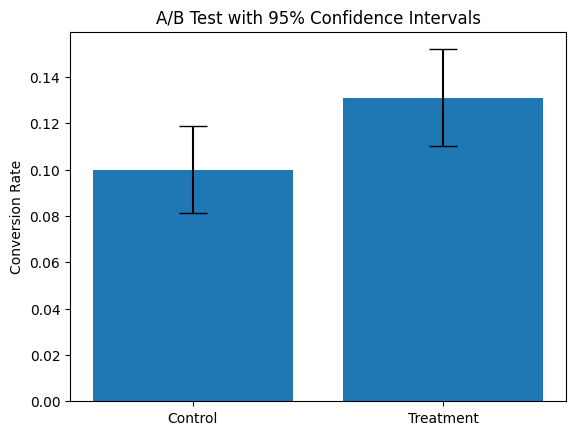

In [22]:
#visualization

labels = ['Control', 'Treatment']
means = [result["control_mean"], result["treatment_mean"]]

# confidence interval width
control_ci = result["control_ci"]
treatment_ci = result["treatment_ci"]

errors = [
    result["control_mean"] - control_ci[0],
    result["treatment_mean"] - treatment_ci[0]
]

plt.bar(labels, means, yerr=errors, capsize=10)

plt.ylabel("Conversion Rate")
plt.title("A/B Test with 95% Confidence Intervals")

plt.show()

In [18]:
print("A/B TEST SUMMARY")
print("----------------------")

print(f"Control conversion rate: {result['control_mean']:.3f}")
print(f"Treatment conversion rate: {result['treatment_mean']:.3f}")

print(f"\nDifference: {result['difference']:.3f}")

print(f"\nt-statistic: {result['t_statistic']:.3f}")
print(f"p-value: {result['p_value']:.4f}")

print(f"\nControl CI: {result['control_ci']}")
print(f"Treatment CI: {result['treatment_ci']}")

print(f"\nDecision: {result['decision']}")

A/B TEST SUMMARY
----------------------
Control conversion rate: 0.100
Treatment conversion rate: 0.131

Difference: 0.031

t-statistic: 2.170
p-value: 0.0301

Control CI: (np.float64(0.08139684512686882), np.float64(0.1186031548731312))
Treatment CI: (np.float64(0.11007762976464512), np.float64(0.15192237023535488))

Decision: Reject H0 (Significant difference)


Treatment conversion rate is higher than control.

The p-value is below 0.05, so we reject the null hypothesis.
This indicates the treatment significantly improves conversion rate.